In [ ]:
!pip install pytrends

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pytrends.request import TrendReq

## Importing Dataset

In [ ]:
#Connect to Google Trends
pytrend = TrendReq()

# Keyword (Website name of which i have to import data)
keyword = ["YouTube"]

#Import last 5 years of data
pytrend.build_payload(kw_list=keyword, timeframe='today 5-y')

In [ ]:
# Get interest over time
data = pytrend.interest_over_time()

C:\Ananconda\Lib\site-packages\pytrends\request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


In [ ]:
data.head()

,YouTube,isPartial
date,,
2021-03-28,88,False
2021-04-04,87,False
2021-04-11,85,False
2021-04-18,89,False
2021-04-25,89,False


In [ ]:
data.drop(columns=['isPartial'],inplace=True)++

In [ ]:
data.head()

,YouTube
date,
2021-03-28,88
2021-04-04,87
2021-04-11,85
2021-04-18,89
2021-04-25,89


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 262 entries, 2021-03-28 to 2026-03-29
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   YouTube  262 non-null    int64
dtypes: int64(1)
memory usage: 4.1 KB


In [ ]:
# Set date as index
data.index = pd.to_datetime(data.index)

In [ ]:
# Rename column for clarity
data.rename(columns={'YouTube': 'Search_Interest'}, inplace=True)

In [ ]:
# Preview data
print(data.head())

            Search_Interest
date                       
2021-03-28               88
2021-04-04               87
2021-04-11               85
2021-04-18               89
2021-04-25               89


# Expolatory Data Analysis

In [ ]:
data.describe

<bound method NDFrame.describe of             Search_Interest
date                       
2021-03-28               88
2021-04-04               87
2021-04-11               85
2021-04-18               89
2021-04-25               89
...                     ...
2026-03-01               91
2026-03-08               89
2026-03-15               86
2026-03-22               88
2026-03-29               84

[262 rows x 1 columns]>

In [ ]:
data.isnull().sum()

Search_Interest    0
dtype: int64

<Axes: xlabel='date'>

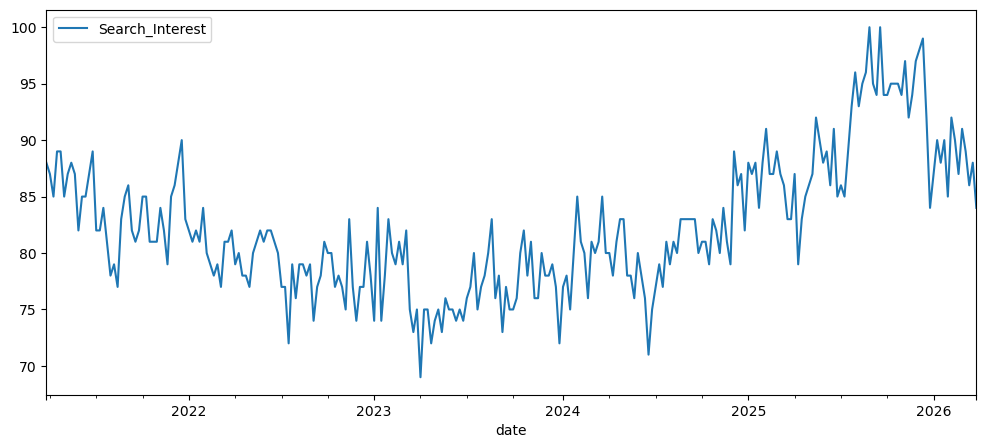

In [ ]:
data.plot(figsize=(12,5))

C:\Users\MAYANK SHARMA\AppData\Local\Temp\ipykernel_2288\77829012.py:1: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  data.resample(rule='A').min().plot()


<Axes: xlabel='date'>

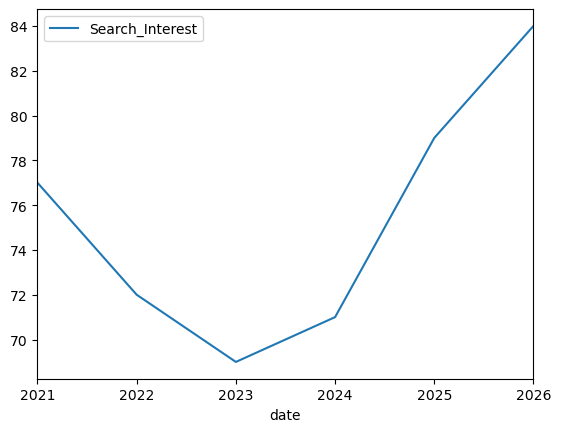

In [ ]:
data.resample(rule='A').min().plot()

C:\Users\MAYANK SHARMA\AppData\Local\Temp\ipykernel_2288\3210958716.py:1: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  data.resample(rule='A').max().plot()


<Axes: xlabel='date'>

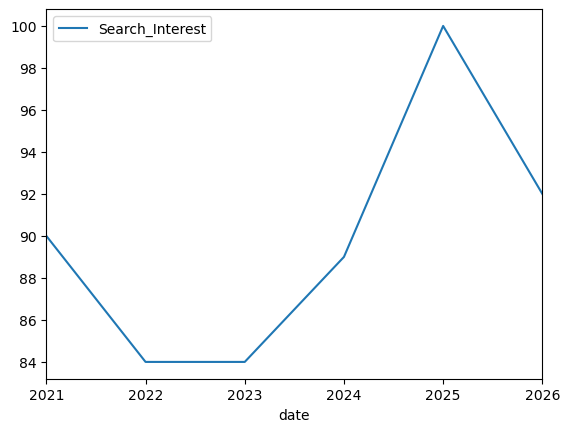

In [ ]:
data.resample(rule='A').max().plot()

C:\Users\MAYANK SHARMA\AppData\Local\Temp\ipykernel_2288\3640779189.py:1: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  data['Search_Interest'].resample(rule='A').mean().plot(kind='bar')


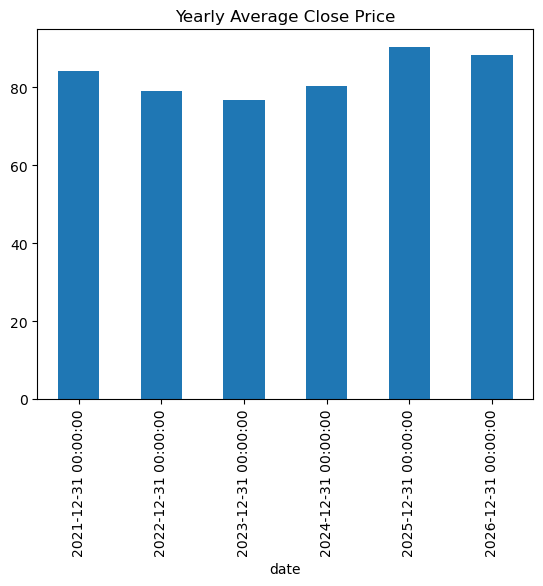

In [ ]:
data['Search_Interest'].resample(rule='A').mean().plot(kind='bar')
plt.title("Yearly Average Close Price")
plt.show()

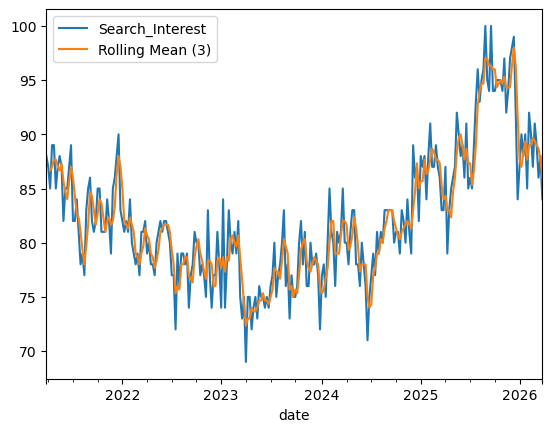

In [ ]:
A = data['Search_Interest'].rolling(3).mean()

data['Search_Interest'].plot()
A.plot(label='Rolling Mean (3)')
plt.legend()
plt.show()

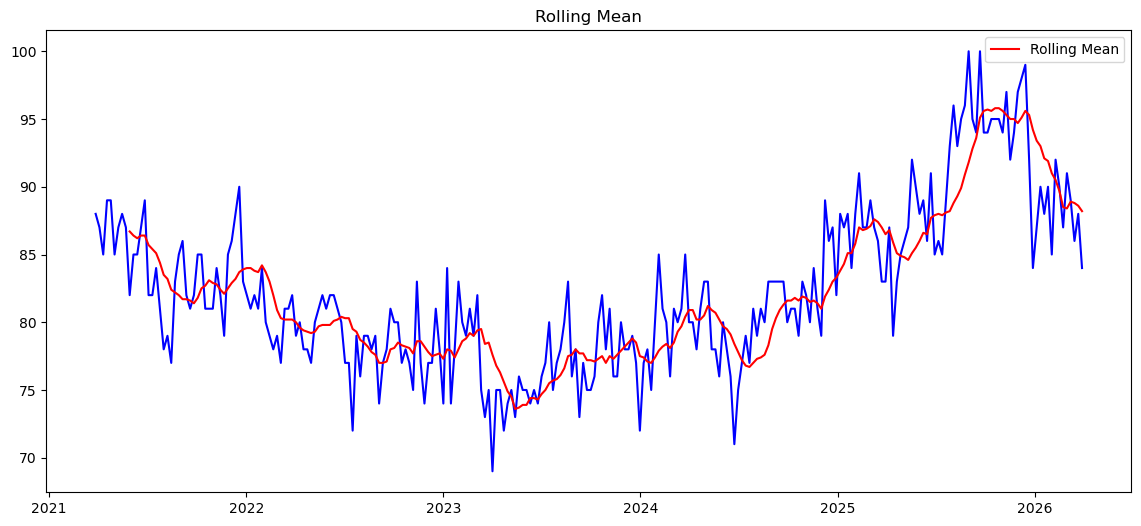

In [ ]:
rolling_mean = data['Search_Interest'].rolling(10).mean()

plt.figure(figsize=(14,6))
plt.plot(data['Search_Interest'], color='blue')
plt.plot(rolling_mean, label='Rolling Mean', color='red')
plt.title('Rolling Mean')
plt.legend()
plt.show()

<Axes: xlabel='date'>

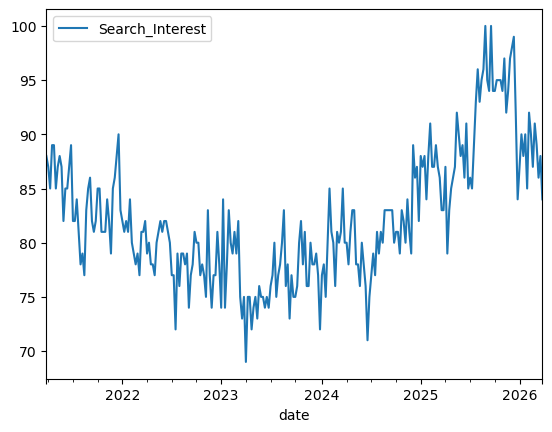

In [ ]:
data.plot()

<Figure size 1200x400 with 0 Axes>

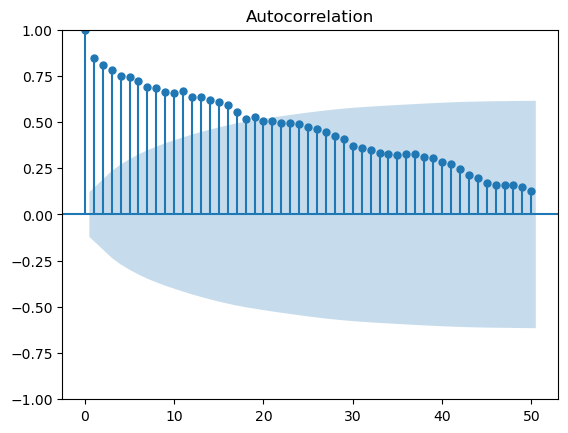

<Figure size 1200x400 with 0 Axes>

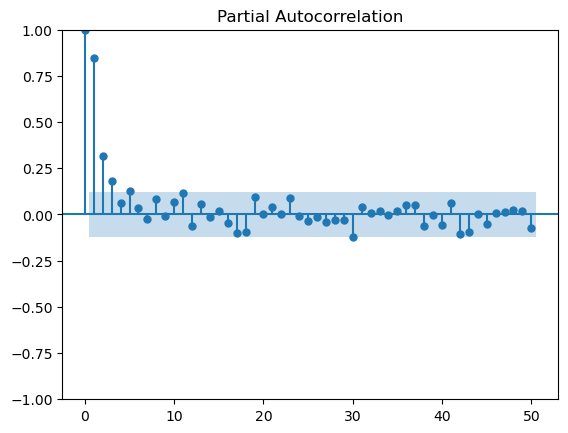

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(12,4))
plot_acf(data['Search_Interest'], lags=50)
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(data['Search_Interest'], lags=50)
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller
def adf_test(series):
    result = adfuller(series)
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    if result[1] <= 0.05:
        print("=> Series is Stationary")
    else:
        print("=> Series is Non-Stationary")

adf_test(data['Search_Interest'])

ADF Statistic: -2.0560940865719517
p-value: 0.26253171392178487
=> Series is Non-Stationary


ADF Statistic: -11.603882857264855
p-value: 2.609155553890931e-21
=> Series is Stationary


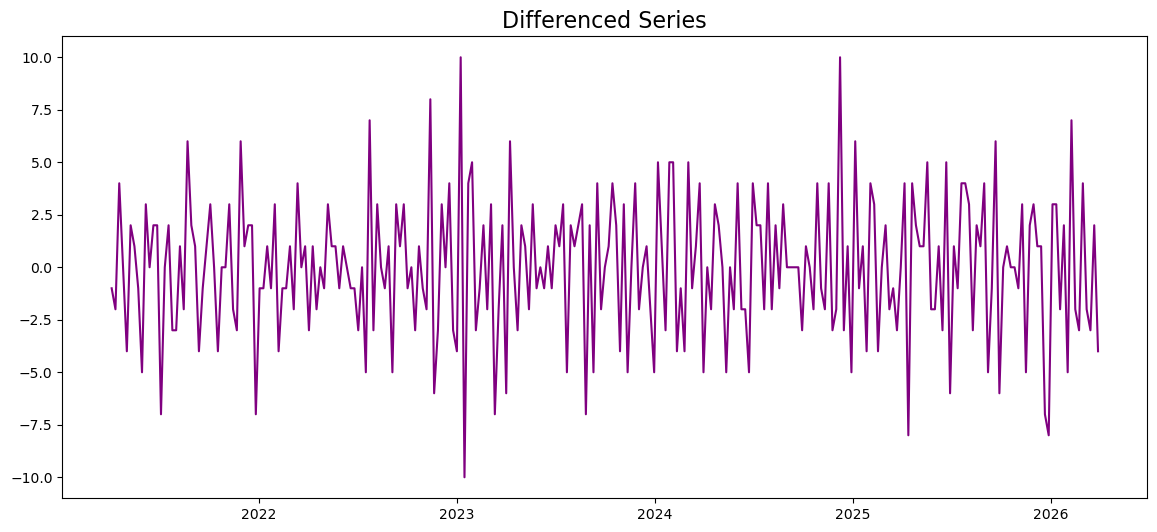

In [ ]:
data_diff = data['Search_Interest'].diff().dropna()
adf_test(data_diff)

# Plot differenced series
plt.figure(figsize=(14,6))
plt.plot(data_diff, color='purple')
plt.title('Differenced Series', fontsize=16)
plt.show()

In [ ]:
train_size = int(len(data) * 0.9)
train, test = data['Search_Interest'][:train_size], data['Search_Interest'][train_size:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 235
Test size: 27


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
p,d,q = 2,1,2  # example values

model = ARIMA(train, order=(p,d,q))
model_fit = model.fit()

print(model_fit.summary())

C:\Ananconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
C:\Ananconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
C:\Ananconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:        Search_Interest   No. Observations:                  235
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -578.417
Date:                Mon, 30 Mar 2026   AIC                           1166.835
Time:                        10:20:26   BIC                           1184.112
Sample:                    03-28-2021   HQIC                          1173.801
                         - 09-21-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6569      0.805      0.816      0.414      -0.920       2.234
ar.L2          0.0087      0.235      0.037      0.970      -0.452       0.469
ma.L1         -1.1897      0.800     -1.486      0.1

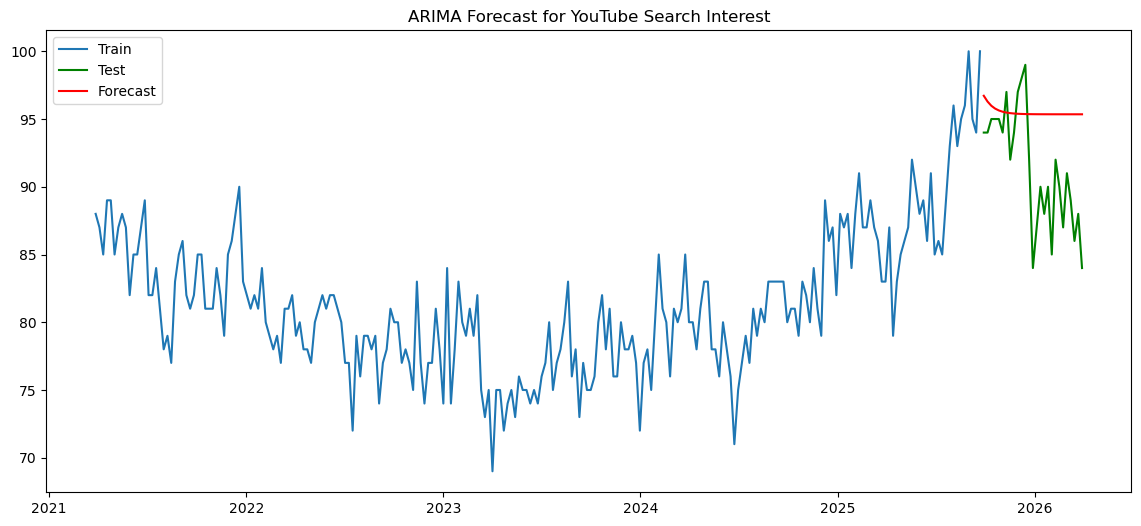

In [ ]:
# Forecast for test period
forecast = model_fit.forecast(steps=len(test))

# Convert to DataFrame
forecast = pd.Series(forecast, index=test.index)

# Plot
plt.figure(figsize=(14,6))
plt.plot(train, label='Train')
plt.plot(test, label='Test', color='green')
plt.plot(forecast, label='Forecast', color='red')
plt.title('ARIMA Forecast for YouTube Search Interest')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = np.sqrt(mean_squared_error(test, forecast))
mae = mean_absolute_error(test, forecast)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 5.847369675069189
MAE: 4.830564176088025


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
model = SARIMAX(train,
                order=(2,1,2),
                seasonal_order=(1,1,1,52))

model_fit = model.fit()

print(model_fit.summary())

C:\Ananconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
C:\Ananconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
C:\Ananconda\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


                                      SARIMAX Results                                       
Dep. Variable:                      Search_Interest   No. Observations:                  235
Model:             SARIMAX(2, 1, 2)x(1, 1, [1], 52)   Log Likelihood                -488.216
Date:                              Mon, 30 Mar 2026   AIC                            990.433
Time:                                      10:20:52   BIC                           1012.861
Sample:                                  03-28-2021   HQIC                           999.525
                                       - 09-21-2025                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6653      1.075      0.619      0.536      -1.441       2.772
ar.L2         -0.00

In [ ]:
forecast = model_fit.forecast(steps=len(test))
forecast = pd.Series(forecast, index=test.index)

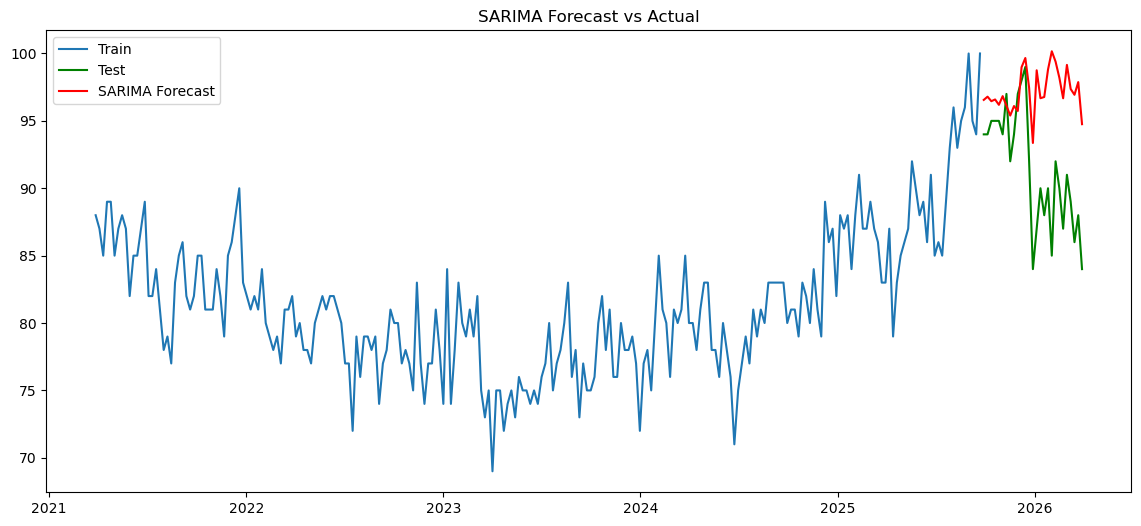

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(train, label='Train')
plt.plot(test, label='Test', color='green')
plt.plot(forecast, label='SARIMA Forecast', color='red')

plt.title('SARIMA Forecast vs Actual')
plt.legend()
plt.show()